# **Preparing the OneHand10K Dataset for Hand Pose Estimation**

This notebook performs the preprocessing of the [OneHand10K](https://www.yangangwang.com/papers/WANG-MCC-2018-10.html) dataset, designed for the task of hand pose estimation. The main goal is to prepare the data for fine-tuning the **YOLO-pose** model from [Ultralytics](https://docs.ultralytics.com/tasks/pose/).

The **OneHand10K** dataset consists of 10,000 training images and 1,703 test images, each containing a single hand. For every hand, segmentation masks are provided, from which the required YOLO bounding box can be derived, along with **21 annotated keypoints** per hand.


## **Imports**

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import drive
from tqdm.auto import tqdm
from glob import glob
import yaml
import os

In [2]:
# Mount Google Drive in Colab
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## **Configuration**

In [26]:
raw_data_path = "/content/drive/MyDrive/Datasets/Raw_OneHand10K.zip"
data_zip_path = "/content/drive/MyDrive/Datasets/OneHand10K.zip"
raw_data_dir = os.path.basename(raw_data_path).split(".")[0]
data_dir = os.path.basename(data_zip_path).split(".")[0]

## **Preprocessing and Saving the Pose Dataset**

To access the download link of the original dataset, it is necessary to request it via email, with the details provided on its [official page](https://www.yangangwang.com/papers/WANG-MCC-2018-10.html). After obtaining it, I uploaded the dataset to my personal Google Drive.

In [4]:
# Extract the raw dataset
!unzip -q $raw_data_path

In the OneHand10K dataset, keypoints that are either occluded or located outside the image boundaries are assigned coordinates $(x, y) = (-1, -1)$. These keypoints are given a visibility value of **0**, while visible keypoints, whose coordinates differ from $(-1, -1)$, are assigned a visibility value of **2**, following the **COCO** format.

In [ ]:
def compute_visibility(keypoints):
    """
    Converts keypoints from the OneHand10K dataset format to the COCO format.

    Args:
        keypoints (list[list[float, float]]): List of keypoints with (x, y) coordinates.
    
    Returns:
        (np.ndarray): Keypoints in COCO format with shape (nkpts, 3), where each row is (x, y, v).
    """
    # Convert to NumPy array with shape (nkpts, 2)
    keypoints = np.array(keypoints, np.float32).reshape(-1, 2)

    # Compute visibility (2 if valid, 0 otherwise) and append it
    v = np.all(keypoints != -1, axis=1)
    keypoints = np.concat([keypoints, v[:, None] * 2], axis=1)

    # Set invisible keypoints to (0, 0, 0)
    keypoints[~v] = 0

    return keypoints


def compute_data(raw_data_dir, split="train"):
    """
    Loads and processes the OneHand10K dataset annotations.

    Args:
        raw_data_dir (str): Path to the root directory containing the dataset.
        split (str, optional): Dataset split to load ("train" or "test"). 

    Returns:
        (pd.DataFrame): DataFrame containing image metadata and keypoints in COCO format.
    """
    # Load raw annotations file
    df = pd.read_csv(os.path.join(raw_data_dir, f"{split.capitalize()}/label_joint.txt"), header=None)
    df = df.rename(columns={0: "filename", 1: "width", 2: "height"})

    # Extract keypoints columns
    df["keypoints"] = df.iloc[:, 4:].apply(lambda x: x.tolist(), axis=1)
    df = df.loc[:, ["filename", "width", "height", "keypoints"]]

    # Convert to COCO format and compute number of visible keypoints
    df["keypoints"] = df.keypoints.apply(compute_visibility)
    df["num_keypoints"] = df.keypoints.apply(lambda x: np.sum(x[:, 2] > 0))

    return df

In [4]:
df_train = compute_data(raw_data_dir)
df_test = compute_data(raw_data_dir, "test")

df_train

,filename,width,height,keypoints,num_keypoints
0,1.jpg,226,222,"[[135.0, 187.0, 2.0], [187.0, 148.0, 2.0], [20...",21
1,2.jpg,226,320,"[[97.0, 306.0, 2.0], [32.0, 222.0, 2.0], [31.0...",19
2,3.jpg,226,118,"[[100.0, 95.0, 2.0], [172.0, 67.0, 2.0], [194....",12
3,4.jpg,226,222,"[[94.0, 209.0, 2.0], [138.0, 126.0, 2.0], [138...",17
4,5.jpg,226,134,"[[119.0, 71.0, 2.0], [99.0, 91.0, 2.0], [95.0,...",18
...,...,...,...,...,...
9995,9996.jpg,378,283,"[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [250.0, 270...",16
9996,9997.jpg,311,210,"[[128.0, 68.0, 2.0], [200.0, 80.0, 2.0], [224....",17
9997,9998.jpg,190,253,"[[13.0, 101.0, 2.0], [39.0, 128.0, 2.0], [78.0...",14
9998,9999.jpg,1024,726,"[[576.0, 514.0, 2.0], [583.0, 435.0, 2.0], [58...",18


In [5]:
print(df_train.info(), "\n")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       10000 non-null  object
 1   width          10000 non-null  int64 
 2   height         10000 non-null  int64 
 3   keypoints      10000 non-null  object
 4   num_keypoints  10000 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 390.8+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703 entries, 0 to 1702
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   filename       1703 non-null   object
 1   width          1703 non-null   int64 
 2   height         1703 non-null   int64 
 3   keypoints      1703 non-null   object
 4   num_keypoints  1703 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 66.7+ KB
None


In [6]:
pd.concat([df_train, df_test]).loc[:, ["width", "height", "num_keypoints"]].describe()

,width,height,num_keypoints
count,11703.000000,11703.000000,11703.000000
mean,1270.270358,1594.688114,15.685636
std,1274.988273,1690.134916,4.022332
min,100.000000,93.000000,2.000000
25%,238.000000,220.000000,13.000000
50%,560.000000,600.000000,16.000000
75%,2448.000000,3264.000000,19.000000
max,5312.000000,5312.000000,21.000000


In [7]:
pd.concat([df_train, df_test]).num_keypoints.value_counts()

,count
num_keypoints,
21,2040
17,1121
18,927
15,880
16,868
19,847
13,847
14,786
12,784


In [8]:
def mask_to_bbox(mask, kpts=None):
    """
    Compute the bounding box coordinates from a binary mask.
    Optionally, ensure that all visible keypoints are included
    within the bounding box.

    Args:
        mask (np.ndarray): Binary mask of shape (height, width).
        kpts (np.ndarray, optional): Array of keypoints with shape (nkpts, 3),
            where each row is (x, y, visibility). If provided, the bounding
            box is expanded to fully include visible keypoints.

    Returns:
        (np.ndarray): Absolute bounding box in [xmin, ymin, xmax, ymax] format.
    """
    # Check if mask is empty
    if not np.any(mask):
        raise ValueError("Empty binary mask provided. Cannot compute bounding box.")

    # Compute bbox from mask
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]
    ymax += 1
    xmax += 1

    # Expand bbox if visible keypoints lie outside
    if kpts is not None:
        vis_mask = kpts[:, 2] > 0
        if np.any(vis_mask):
            k_xmin, k_ymin = kpts[vis_mask, :2].min(axis=0)
            k_xmax, k_ymax = kpts[vis_mask, :2].max(axis=0)
            height, width = mask.shape

            xmin = max(min(xmin, k_xmin), 0)
            ymin = max(min(ymin, k_ymin), 0)
            xmax = min(max(xmax, k_xmax), width)
            ymax = min(max(ymax, k_ymax), height)

    return np.array([xmin, ymin, xmax, ymax], np.float32)

Unfortunately, the original OneHand10K dataset contains numerous anomalies. There are images and/or segmentation masks that are rotated and do not match the keypoint values. In addition, some keypoint IDs are incorrectly annotated or in the wrong order.

If all of these samples were discarded, only a very small number of useful images would remain. For this reason, I manually reviewed each image along with its keypoints and masks to correct these inconsistencies. Through this process, I was able to identify patterns that allowed me to recover almost all of the images. I only marked 40 training images and one test image as corrupted (so the evaluation will not be affected), and removed them since they did not follow any correctable pattern and could only be reused through re-annotation.

In [ ]:
anomalies = {
    # Images to rotate 180° clockwise
    "rotate_img": [
        "2036.jpg", "2037.jpg", "2247.jpg", "2248.jpg", "2249.jpg", "2251.jpg", "2252.jpg", "2253.jpg", "2254.jpg", "2255.jpg",
        "2256.jpg", "2257.jpg", "2258.jpg", "2259.jpg", "2260.jpg", "2262.jpg", "2263.jpg", "2264.jpg", "2265.jpg", "2266.jpg",
        "2267.jpg", "2268.jpg", "2269.jpg", "2270.jpg", "2271.jpg", "2272.jpg", "2273.jpg", "2274.jpg", "2275.jpg", "2276.jpg",
        "2277.jpg", "2278.jpg", "2279.jpg", "10706.jpg", "11665.jpg", "11666.jpg"
    ],
    # Segmentation masks to rotate 90° counterclockwise
    "rotate_mask": [
        "1089.jpg", "2338.jpg", "2344.jpg", "3950.jpg"
    ],
    # Images to rotate 90° clockwise and masks to rotate 90° counterclockwise
    "rotate_img_mask": [
        "866.jpg"
    ],
    # Corrupted images to remove
    "corrupt": [
        "1387.jpg", "2063.jpg", "2211.jpg", "2468.jpg", "2504.jpg", "2619.jpg", "295.jpg", "347.jpg", "399.jpg", "41.jpg",
        "4649.jpg", "4776.jpg", "4787.jpg", "480.jpg", "497.jpg", "510.jpg", "520.jpg", "5665.jpg", "7758.jpg", "8024.jpg",
        "8137.jpg", "8564.jpg", "9710.jpg", "9803.jpg", "11361.jpg", "825.jpg", "1971.jpg", "20.jpg", "201.jpg", "2182.jpg",
        "2770.jpg", "2777.jpg", "297.jpg", "305.jpg", "3266.jpg", "4759.jpg", "7745.jpg", "8069.jpg", "8455.jpg", "8654.jpg",
        "9530.jpg"
    ]
}

# Mapping dictionary to fix keypoints with misordered or incorrectly annotated IDs
reorder_map = {
    "10030.jpg": lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "10695.jpg": lambda kpts: np.concat([kpts[1:9], kpts[:1], kpts[9:]], axis=0),
    "1815.jpg":  lambda kpts: np.concat([kpts[-1:], kpts[:-1]], axis=0),
    "1969.jpg":  lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "212.jpg":   lambda kpts: np.concat([kpts[:5], kpts[6:], kpts[5:6]], axis=0),
    "2332.jpg":  lambda kpts: np.concat([kpts[1:], kpts[:1]], axis=0),
    "260.jpg":   lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "296.jpg":   lambda kpts: np.concat([kpts[1:19], kpts[:1], kpts[19:]], axis=0),
    "31.jpg":    lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "3132.jpg":  lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "370.jpg":   lambda kpts: np.concat([kpts[:9], kpts[-1:], kpts[9:-1]], axis=0),
    "4532.jpg":  lambda kpts: np.concat([kpts[:6], kpts[10:], kpts[6:10]], axis=0),
    "4661.jpg":  lambda kpts: np.concat([kpts[:1], kpts[17:], kpts[1:17]], axis=0),
    "4725.jpg":  lambda kpts: np.concat([kpts[-1:], kpts[:-1]], axis=0),
    "504.jpg":   lambda kpts: np.concat([kpts[:13], kpts[18:], kpts[13:18]], axis=0),
    "591.jpg":   lambda kpts: np.concat([kpts[:10], kpts[-1:], kpts[10:12], kpts[14:15], kpts[12:14], kpts[15:-1]], axis=0),
    "9336.jpg":  lambda kpts: np.concat([kpts[:5], kpts[6:], kpts[5:6]], axis=0),
    "9658.jpg":  lambda kpts: np.concat([kpts[1:], kpts[:1]], axis=0),
    "9735.jpg":  lambda kpts: np.concat([kpts[16:17], kpts[:16], kpts[17:]], axis=0),
    "9905.jpg":  lambda kpts: np.concat([kpts[-1:], kpts[:-1]], axis=0),
    "10184.jpg": lambda kpts: np.concat([kpts[:9], kpts[-1:], kpts[9:-1]], axis=0),
    "11242.jpg": lambda kpts: np.concat([kpts[:9], kpts[10:], kpts[9:10]], axis=0),
    "14.jpg":    lambda kpts: np.concat([kpts[:9], kpts[10:], kpts[9:10]], axis=0),
    "2243.jpg":  lambda kpts: np.concat([kpts[:13], kpts[-1:], kpts[13:-1]], axis=0),
    "3176.jpg":  lambda kpts: np.concat([kpts[:3], kpts[-2:], kpts[3:-2]], axis=0),
    "9721.jpg":  lambda kpts: np.concat([kpts[:4], kpts[-1:], kpts[4:-1]], axis=0),
    "3101.jpg":  lambda kpts: np.concat([kpts[:5], kpts[6:13], kpts[13:], [[0, 0, 0]]], axis=0),
    "411.jpg":   lambda kpts: np.concat([kpts[:17], kpts[18:20], kpts[17:18], kpts[20:]], axis=0),
    "100.jpg":   lambda kpts: np.concat([kpts[:11], kpts[15:16], kpts[11:15], kpts[16:]], axis=0),
    "4551.jpg":  lambda kpts: np.concat([kpts[:13], kpts[14:], [[200, 210, 2]]], axis=0),
    "8086.jpg":  lambda kpts: np.concat([kpts[:16], [[218, 16, 2]], kpts[17:]], axis=0)
}

Unlike other pose estimation models that typically follow a two-stage approach, **YOLO-pose** operates in a single stage. This is similar to a bottom-up approach but without the need to generate heatmaps, meaning keypoint coordinates do not need to be integers.

For pose estimation, **Ultralytics** expects each row of the label file corresponding to an image to follow the [format](https://docs.ultralytics.com/datasets/pose/):

```
<class_id> <x_center> <y_center> <width> <height> <x1> <y1> <v1> ... <xn> <yn> <vn>
```

Where:

* **x_center** and **y_center** are the coordinates of the object's bounding box center, normalized by the image width and height.
* **width** and **height** are the normalized width and height of the bounding box.
* **x1, y1, v1, ..., xn, yn, vn** are the keypoint coordinates normalized by the image dimensions.

It is important to note that the pose estimation metrics used by Ultralytics are based on the [Object Keypoint Similarity (OKS)](https://cocodataset.org/#keypoints-eval) metric. In this case, the segmented area of the object is not required, as it is heuristically estimated to be approximately 53% of the object's bounding box area, as indicated in the [Ultralytics documentation](https://github.com/ultralytics/ultralytics/blob/35a4b17d9bd549e77d6b65f86c0f844288cbb1ac/ultralytics/models/yolo/pose/val.py#L197).

In [ ]:
def preprocess_and_save(raw_data_dir, data_dir, df, split="train", max_size=(720, 1280)):
    """
    Preprocess dataset annotations and save them in Ultralytics YOLO format for pose estimation.

    Args:
        raw_data_dir (str): Path to the raw dataset containing images and annotations.
        data_dir (str): Path where the processed dataset will be stored.
        df (pd.DataFrame): DataFrame with image filenames, keypoints, width, and height.
        split (str, optional): Dataset split, either 'train' or 'test'. Default is 'train'.
        max_size (tuple[int, int]): Maximum image size (height, width) to save, reducing storage and
            computation during training and evaluation.
    """
    if split not in {"train", "test"}:
        raise ValueError("Invalid dataset split. Choose either 'train' or 'test'.")

    # Create directories for processed images and labels
    images_dir = os.path.join(data_dir, split, "images")
    labels_dir = os.path.join(data_dir, split, "labels")
    os.makedirs(data_dir, exist_ok=True)
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Skip corrupted files
        filename = row["filename"]
        if filename in anomalies["corrupt"]:
            print(f"File {filename} contains invalid keypoint annotations.")
            continue

        # Get image dimensions (swap if rotation mask is required) and build paths
        rotation_mask = (filename in anomalies["rotate_mask"]) or (filename in anomalies["rotate_img_mask"])
        width, height = row[["width", "height"]] if not rotation_mask else row[["height", "width"]]
        img_path = os.path.join(raw_data_dir, f"{split.capitalize()}/source/{filename}")
        mask_path = os.path.join(raw_data_dir, f"{split.capitalize()}/mask/{filename.replace('.jpg', '.png')}")

        # Load and fix keypoints if reordering is required
        keypoints = row["keypoints"].copy()
        if filename in reorder_map:
            keypoints = reorder_map[filename](keypoints)

        # Mask keypoints outside image boundaries instead of discarding the sample
        corrupt_mask = (keypoints[:, 2] > 0) & (
            (keypoints[:, 0] > width) | (keypoints[:, 1] > height) |
            (keypoints[:, 0] < 0) | (keypoints[:, 1] < 0)
        )
        if np.any(corrupt_mask):
            keypoints[corrupt_mask] = 0

        # Load binary segmentation mask
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask >= 100).astype(np.uint8)

        # Rotate mask 90° counterclockwise if required
        if rotation_mask:
            mask = np.rot90(mask, k=1)

        # Compute bounding box and normalize to YOLO format
        xmin, ymin, xmax, ymax = mask_to_bbox(mask, keypoints)
        bbox = [
            (xmax + xmin) / (2 * width),
            (ymax + ymin) / (2 * height),
            (xmax - xmin) / width,
            (ymax - ymin) / height
        ]

        # Normalize keypoints
        keypoints[:, 0] /= width
        keypoints[:, 1] /= height

        # Rotate image 180° clockwise if listed in 'rotate_img'
        image = np.array(Image.open(img_path).convert("RGB"))
        if filename in anomalies["rotate_img"]:
            image = np.rot90(image, k=-2)
        
        # Rotate image 90° clockwise if annotation/image dimensions mismatch or if listed in 'rotate_img_mask'
        img_height, img_width = image.shape[:2]
        if ((width != img_width) or (height != img_height)) and (filename not in anomalies["rotate_mask"]):
            image = np.rot90(image, k=-1)

        # Save YOLO label file
        label = [0] + bbox + keypoints.flatten().tolist()
        with open(os.path.join(labels_dir, filename.split(".jpg")[0] + ".txt"), "w") as f:
            f.write(" ".join(map(str, label)))

        # Save resized image
        image = Image.fromarray(image)
        image.thumbnail(max_size[::-1])
        image.save(os.path.join(images_dir, filename))

In [30]:
preprocess_and_save(raw_data_dir, data_dir, df_train)
preprocess_and_save(raw_data_dir, data_dir, df_test, split="test")

  0%|          | 0/10000 [00:00<?, ?it/s]

File 20.jpg contains invalid keypoint annotations.
File 41.jpg contains invalid keypoint annotations.
File 201.jpg contains invalid keypoint annotations.
File 295.jpg contains invalid keypoint annotations.
File 297.jpg contains invalid keypoint annotations.
File 305.jpg contains invalid keypoint annotations.
File 347.jpg contains invalid keypoint annotations.
File 399.jpg contains invalid keypoint annotations.
File 480.jpg contains invalid keypoint annotations.
File 497.jpg contains invalid keypoint annotations.
File 510.jpg contains invalid keypoint annotations.
File 520.jpg contains invalid keypoint annotations.
File 825.jpg contains invalid keypoint annotations.
File 1387.jpg contains invalid keypoint annotations.
File 1971.jpg contains invalid keypoint annotations.
File 2063.jpg contains invalid keypoint annotations.
File 2182.jpg contains invalid keypoint annotations.
File 2211.jpg contains invalid keypoint annotations.
File 2468.jpg contains invalid keypoint annotations.
File 250

  0%|          | 0/1703 [00:00<?, ?it/s]

File 11361.jpg contains invalid keypoint annotations.


In [31]:
# Number of images and labels after preprocessing
print(
    len(os.listdir(os.path.join(data_dir, "train/images"))),
    len(os.listdir(os.path.join(data_dir, "train/labels")))
)

print(
    len(os.listdir(os.path.join(data_dir, "test/images"))),
    len(os.listdir(os.path.join(data_dir, "test/labels")))
)

9960 9960
1702 1702


In pose estimation, it is important to know each keypoint's name, its ID, and the ID of the keypoint it connects to. This information is essential for understanding the dataset structure and accurately visualizing the keypoints during inference.

To achieve this, a dictionary called **skeleton** is defined. Each key corresponds to a keypoint name, and its value is another dictionary containing two elements: a list of two IDs (the first is the keypoint ID and the second is the ID of the connected keypoint), and the RGB color assigned to that keypoint.

In addition, **YOLO-pose** requires a list named **flip_idx** for random horizontal flipping during data augmentation. This list specifies the IDs of symmetric keypoints that should be swapped during the flip, while asymmetric ones remain unchanged. Since OneHand10K does not have symmetric keypoints, **flip_idx** simply contains the keypoint IDs in order.

In [ ]:
skeleton = {
    "wrist": {"ids": [0, 0], "color": [100, 100, 100]},
    "thumb_cmc": {"ids": [1, 0], "color": [0, 0, 100]},
    "thumb_mcp": {"ids": [2, 1], "color": [0, 0, 150]},
    "thumb_ip": {"ids": [3, 2], "color": [0, 0, 200]},
    "thumb_tip": {"ids": [4, 3], "color": [0, 0, 255]},
    "index_finger_mcp": {"ids": [5, 0], "color": [0, 100, 100]},
    "index_finger_pip": {"ids": [6, 5], "color": [0, 150, 150]},
    "index_finger_dip": {"ids": [7, 6], "color": [0, 200, 200]},
    "index_finger_tip": {"ids": [8, 7], "color": [0, 255, 255]},
    "middle_finger_mcp": {"ids": [9, 0], "color": [50, 100, 0]},
    "middle_finger_pip": {"ids": [10, 9], "color": [75, 150, 0]},
    "middle_finger_dip": {"ids": [11, 10], "color": [100, 200, 0]},
    "middle_finger_tip": {"ids": [12, 11], "color": [125, 255, 0]},
    "ring_finger_mcp": {"ids": [13, 0], "color": [100, 50, 0]},
    "ring_finger_pip": {"ids": [14, 13], "color": [150, 75, 0]},
    "ring_finger_dip": {"ids": [15, 14], "color": [200, 100, 0]},
    "ring_finger_tip": {"ids": [16, 15], "color": [255, 125, 0]},
    "pinky_mcp": {"ids": [17, 0], "color": [100, 0, 100]},
    "pinky_pip": {"ids": [18, 17], "color": [150, 0, 150]},
    "pinky_dip": {"ids": [19, 18], "color": [200, 0, 200]},
    "pinky_tip": {"ids": [20, 19], "color": [255, 0, 255]},
}

# Create and save the YAML file with the dataset metadata
nkpts = len(skeleton)
metadata = {
    "path": f"../{data_dir}",
    "train": "train/images",
    "val": "test/images",

    "skeleton": skeleton,
    "kpt_shape": [nkpts, 3],
    "flip_idx": np.arange(nkpts).tolist(),

    "names": {0: "hand"}
}

with open(os.path.join(data_dir, "data.yaml"), "w") as f:
  yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

In [33]:
!du -sh $data_dir

332M	OneHand10K


In [143]:
# Compress and save the preprocessed pose dataset in ZIP format
!zip -r $data_zip_path $data_dir -q

## **Visualization Example**

In [ ]:
class PoseVisualizer():
    """
    Visualizes pose keypoints, skeletons and bounding boxes from YOLO-format annotations.

    Args:
        skeleton (dict[str, dict]): Dictionary where each key is a keypoint name, and its value is a dict with:
            - ids: list of two integers indicating the keypoint pair for a skeleton edge.
            - color: RGB list for drawing the edge/keypoint.
    """

    def __init__(self, skeleton):
        self.skeleton = skeleton

    def draw_keypoints(self, ax, keypoints, show_kpts=True, show_lines=True, show_kpts_ids=True):
        """
        Draws keypoints and connecting skeleton lines on a given Matplotlib Axes.

        Args:
            ax (plt.Axes): Matplotlib Axes to draw on.
            keypoints (np.ndarray): Array of shape (nkpts, 3), with (x, y, visibility).
            show_kpts (bool, optional): Whether to draw keypoint circles.
            show_lines (bool, optional): Whether to draw lines between keypoint pairs.
            show_kpts_ids (bool, optional): Whether to label keypoints with their index.
        """
        for dic in self.skeleton.values():
            ids = dic["ids"]
            color = np.array(dic["color"]) / 255

            # Draw connecting line only if both keypoints are visible
            if show_lines and np.all(keypoints[ids, 2] > 0):
                ax.plot(
                    keypoints[ids, 0],
                    keypoints[ids, 1],
                    color=color,
                    linewidth=1.75 if show_kpts_ids else 1.5,
                    zorder=1
                )

            # Draw individual keypoint if visible
            id = ids[0]
            x, y, v = keypoints[id]
            if v > 0:
                # Draw keypoint as a circle
                if show_kpts:
                    ax.scatter(
                        x, y,
                        color=color,
                        s=(50 if id > 9 else 40) if show_kpts_ids else 25,
                        zorder=2
                    )

                # Display keypoint ID as label
                if show_kpts_ids:
                    ax.text(
                        x, y, str(id),
                        fontsize=5, fontweight="bold",
                        ha="center", va="center", zorder=3
                    )

    def visualize(
        self, image_paths, label_paths, n_rows=2, n_cols=2, random=True,
        show_kpts=True, show_lines=True, show_kpts_ids=True, show_boxes=True,
    ):
        """
        Displays a grid of images with overlaid pose annotations.

        Args:
            image_paths (list[str]): Paths to images.
            label_paths (list[str]): Corresponding YOLO-format label file paths.
            n_rows (int, optional): Number of rows in the grid.
            n_cols (int, optional): Number of columns in the grid.
            random (bool, optional): Whether to shuffle images.
            show_kpts (bool, optional): Whether to display keypoint markers.
            show_lines (bool, optional): Whether to display skeleton lines.
            show_kpts_ids (bool, optional): Whether to label keypoints with their index.
            show_boxes (bool, optional): Whether to draw bounding boxes.
        """
        indices = np.arange(len(image_paths))
        if random:
            np.random.shuffle(indices)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.8 * n_rows))
        axes = axes.flatten() if (n_rows * n_cols) > 1 else [axes]

        for i, ax in enumerate(axes):
            idx = indices[i]

            # Load and show image
            image = np.array(Image.open(image_paths[idx]).convert("RGB"))
            height, width = image.shape[:2]
            ax.imshow(image)
            ax.axis("off")

            # Read labels file
            labels = np.loadtxt(label_paths[idx], np.float32, ndmin=2)

            for label in labels:
                # Extract, denormalize and draw keypoints coordinates
                kpts = label[5:].reshape(-1, 3)
                kpts[:, 0] *= width
                kpts[:, 1] *= height
                self.draw_keypoints(ax, kpts, show_kpts=show_kpts, show_lines=show_lines, show_kpts_ids=show_kpts_ids)

                if show_boxes:
                    # Extract, denormalize and draw bbox coordinates
                    x_center, y_center, w, h = label[1:5]
                    xmin = (x_center - (w / 2)) * width
                    ymin = (y_center - (h / 2)) * height
                    w *= width
                    h *= height
                    rect = patches.Rectangle((xmin, ymin), w, h, linewidth=1.75, edgecolor="red", facecolor="none")
                    ax.add_patch(rect)

        plt.tight_layout()
        plt.show()

In [122]:
visualizer = PoseVisualizer(skeleton)

In [80]:
# Retrieve the file paths for training images and labels
split = "train"
image_paths = np.sort(glob(os.path.join(data_dir, f"{split}/images/*.jpg")))
label_paths = np.sort(glob(os.path.join(data_dir, f"{split}/labels/*.txt")))

len(image_paths), len(label_paths)

(9960, 9960)

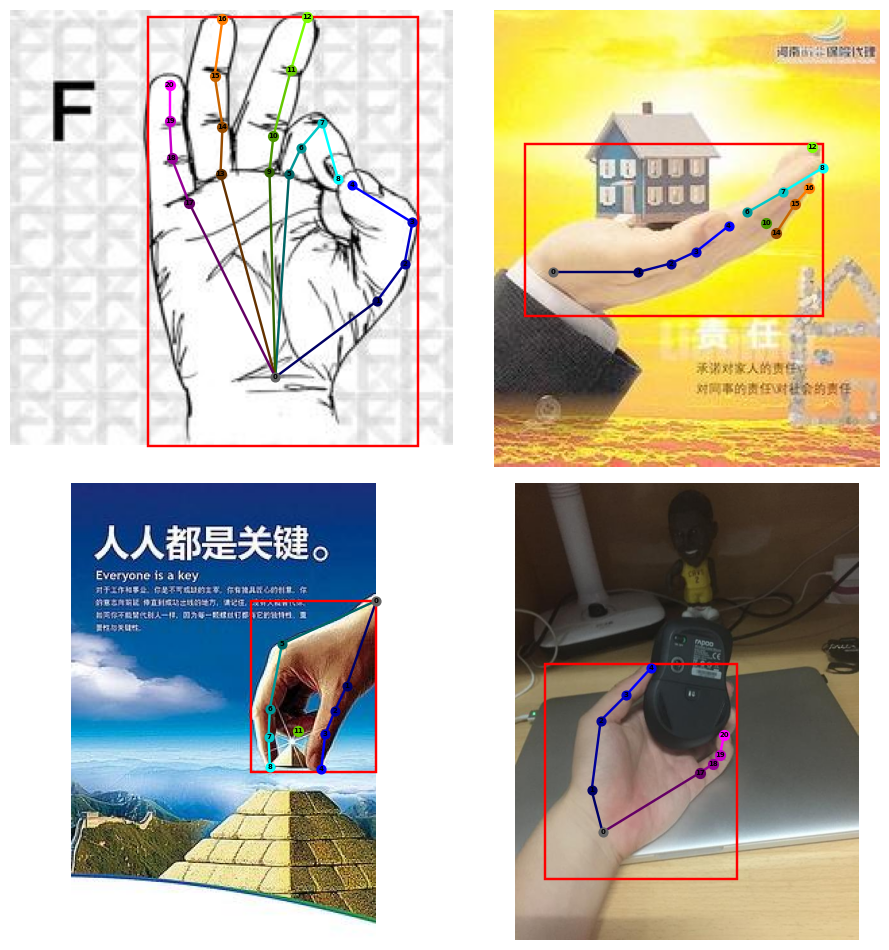

In [124]:
visualizer.visualize(image_paths, label_paths, random=False)

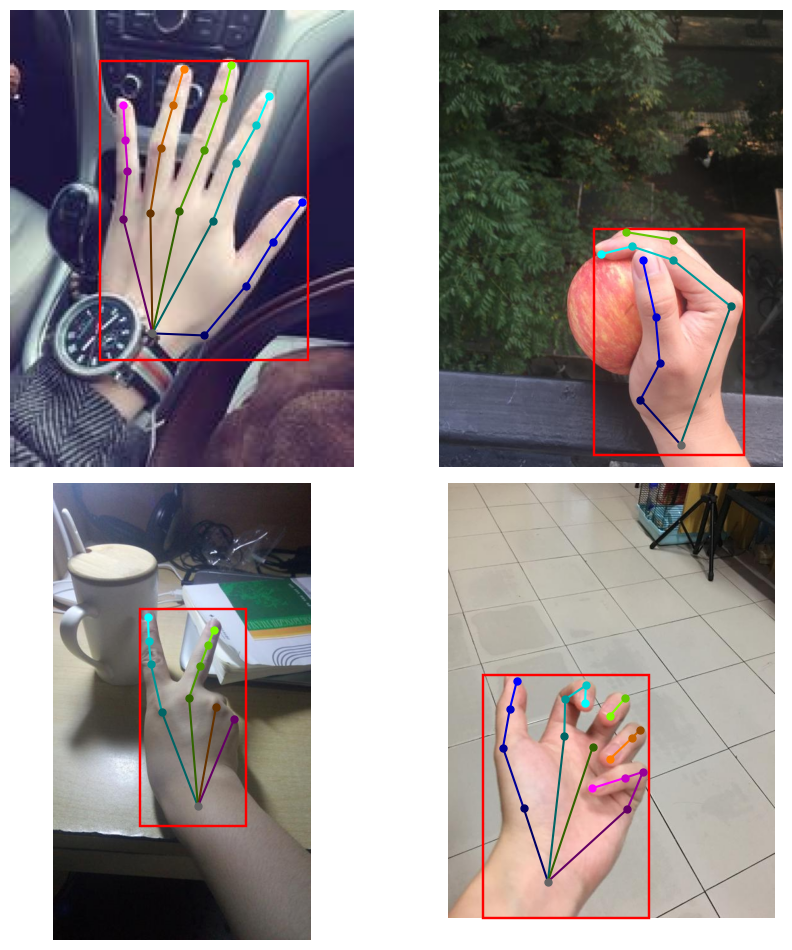

In [136]:
visualizer.visualize(image_paths, label_paths, show_kpts_ids=False)

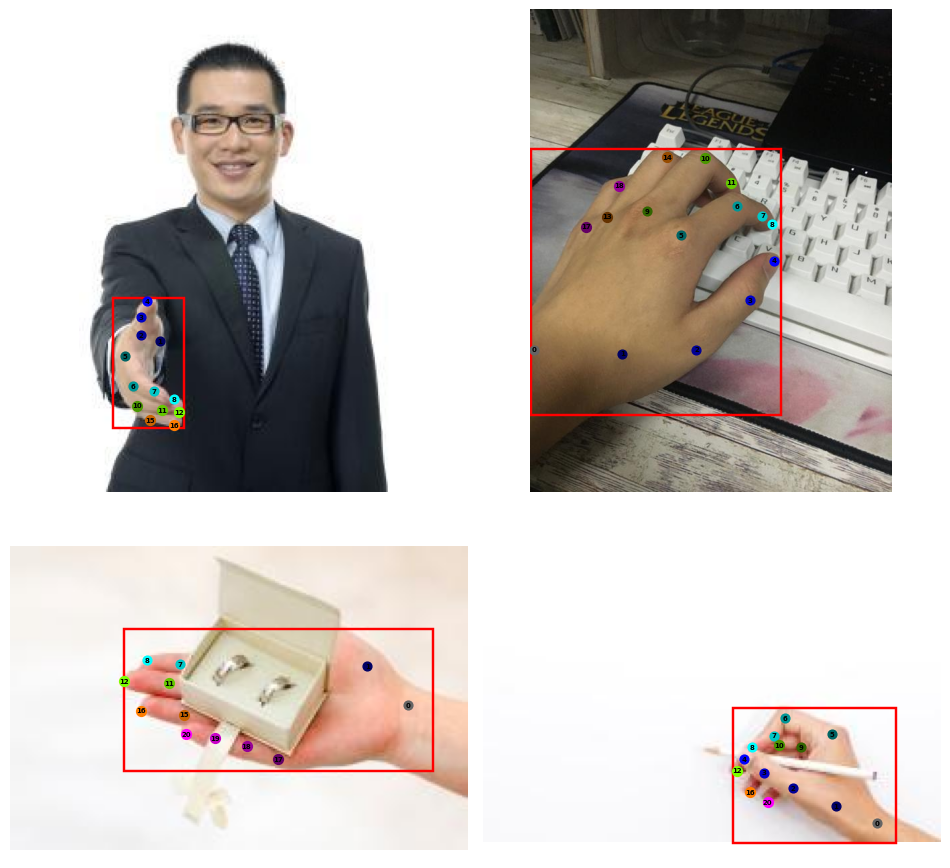

In [137]:
visualizer.visualize(image_paths, label_paths, show_lines=False)